# Cyclical Learning Rate in PyTorch

In [1]:
import numpy as np


def cyclical_learning_rate(batch_step,
                           step_size,
                           base_lr=0.001,
                           max_lr=0.006,
                           mode='triangular',
                           gamma=0.999995):

    cycle = np.floor(1 + batch_step / (2. * step_size))
    x = np.abs(batch_step / float(step_size) - 2 * cycle + 1)

    lr_delta = (max_lr - base_lr) * np.maximum(0, (1 - x))
    
    if mode == 'triangular':
        pass
    elif mode == 'triangular2':
        lr_delta = lr_delta * 1 / (2. ** (cycle - 1))
    elif mode == 'exp_range':
        lr_delta = lr_delta * (gamma**(batch_step))
    else:
        raise ValueError('mode must be "triangular", "triangular2", or "exp_range"')
        
    lr = base_lr + lr_delta
    
    return lr

In [2]:
num_epochs = 50
num_train = 50000
batch_size = 100
iter_per_ep = num_train // batch_size

**Triangular**

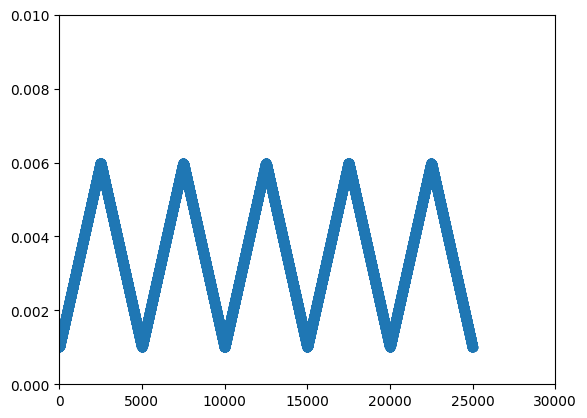

In [3]:
import matplotlib.pyplot as plt


batch_step = -1
collect_lr = []
for e in range(num_epochs):
    for i in range(iter_per_ep):
        batch_step += 1
        cur_lr = cyclical_learning_rate(batch_step=batch_step,
                                        step_size=iter_per_ep*5)
        
        collect_lr.append(cur_lr)
        
plt.scatter(range(len(collect_lr)), collect_lr)
plt.ylim([0.0, 0.01])
plt.xlim([0, num_epochs*iter_per_ep + 5000])
plt.show()

**Triangular2**

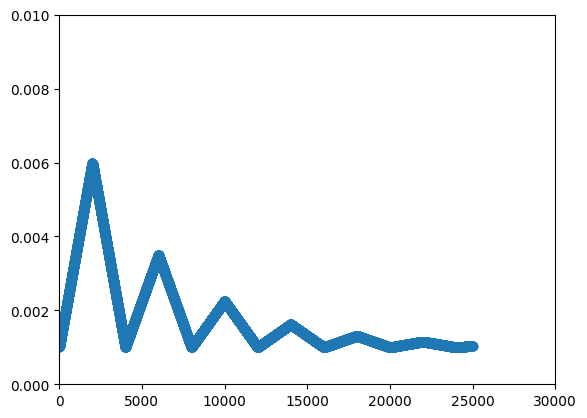

In [4]:
collect_lr = []
batch_step = -1
for e in range(num_epochs):
    for i in range(iter_per_ep):
        batch_step += 1
        cur_lr = cyclical_learning_rate(batch_step=batch_step,
                                        step_size=iter_per_ep*4,
                                        mode='triangular2')
        
        collect_lr.append(cur_lr)
        
plt.scatter(range(len(collect_lr)), collect_lr)
plt.ylim([0.0, 0.01])
plt.xlim([0, num_epochs*iter_per_ep + 5000])
plt.show()

**Exp_range**

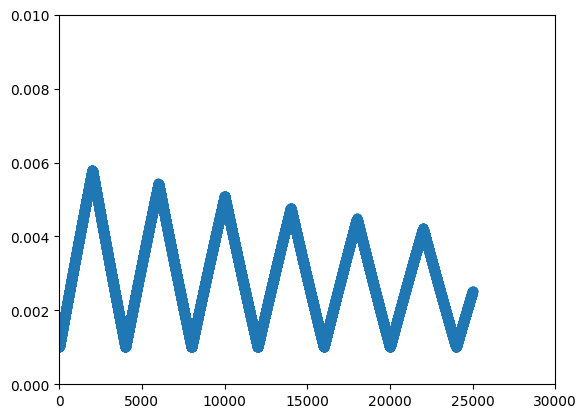

In [5]:
collect_lr = []
batch_step = -1
for e in range(num_epochs):
    for i in range(iter_per_ep):
        batch_step += 1
        cur_lr = cyclical_learning_rate(batch_step=batch_step,
                                        step_size=iter_per_ep*4,
                                        mode='exp_range',
                                        gamma=0.99998)
        
        collect_lr.append(cur_lr)
        
plt.scatter(range(len(collect_lr)), collect_lr)
plt.ylim([0.0, 0.01])
plt.xlim([0, num_epochs*iter_per_ep + 5000])
plt.show()

## Torch Imports

In [6]:
import time
import torch
import torch.nn.functional as F
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data import DataLoader


if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

## Settings

In [10]:
# Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Hyperparameters
random_seed = 1
batch_size = 128

# Architecture
num_classes = 10

## CIFAR-10 DATASET

In [11]:
from torch.utils.data import random_split, DataLoader, SubsetRandomSampler
import numpy as np

# Split indices for train/validation
num_train = len(train_dataset)
indices = list(range(num_train))
split = int(0.8 * num_train)  # 80% train, 20% val

np.random.shuffle(indices)
train_idx, val_idx = indices[:split], indices[split:]

train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)

# Now DataLoaders
train_loader = DataLoader(dataset=train_dataset, 
                          batch_size=batch_size, 
                          sampler=train_sampler)

val_loader = DataLoader(dataset=train_dataset, 
                        batch_size=batch_size, 
                        sampler=val_sampler)

test_loader = DataLoader(dataset=test_dataset, 
                         batch_size=batch_size, 
                         shuffle=False)

## Model

In [12]:
class ConvNet(torch.nn.Module):

    def __init__(self, num_classes):
        super(ConvNet, self).__init__()
        
        # 32x32x3 => 32x32x6
        self.conv_1 = torch.nn.Conv2d(in_channels=3,
                                      out_channels=6,
                                      kernel_size=(3, 3),
                                      stride=(1, 1),
                                      padding=1) # (1(32-1) - 32 + 3) / 2) = 1
        # 32x32x4 => 16x16x6
        self.pool_1 = torch.nn.MaxPool2d(kernel_size=(2, 2),
                                         stride=(2, 2),
                                         padding=0) # (2(16-1) - 32 + 2) = 0                                       
        
        
        # 16x16x6 => 16x16x12
        self.conv_2 = torch.nn.Conv2d(in_channels=6,
                                      out_channels=12,
                                      kernel_size=(3, 3),
                                      stride=(1, 1),
                                      padding=1) # (1(16-1) - 16 + 3) / 2 = 1                 
        # 16x16x12 => 8x8x12                             
        self.pool_2 = torch.nn.MaxPool2d(kernel_size=(2, 2),
                                         stride=(2, 2),
                                         padding=0) # (2(8-1) - 16 + 2) = 0
        
        
        # 8x8x12 => 8x8x18
        self.conv_3 = torch.nn.Conv2d(in_channels=12,
                                      out_channels=18,
                                      kernel_size=(3, 3),
                                      stride=(1, 1),
                                      padding=1) # (1(8-1) - 8 + 3) / 2 = 1                 
        # 8x8x18 => 4x4x18                             
        self.pool_3 = torch.nn.MaxPool2d(kernel_size=(2, 2),
                                         stride=(2, 2),
                                         padding=0) # (2(4-1) - 8 + 2) = 0
        
        
        # 4x4x18 => 4x4x24
        self.conv_4 = torch.nn.Conv2d(in_channels=18,
                                      out_channels=24,
                                      kernel_size=(3, 3),
                                      stride=(1, 1),
                                      padding=1)                 
        # 4x4x24 => 2x2x24                             
        self.pool_4 = torch.nn.MaxPool2d(kernel_size=(2, 2),
                                         stride=(2, 2),
                                         padding=0)
        
        
        # 2x2x24 => 2x2x30
        self.conv_5 = torch.nn.Conv2d(in_channels=24,
                                      out_channels=30,
                                      kernel_size=(3, 3),
                                      stride=(1, 1),
                                      padding=1)                 
        # 2x2x30 => 1x1x30                             
        self.pool_5 = torch.nn.MaxPool2d(kernel_size=(2, 2),
                                         stride=(2, 2),
                                         padding=0)
        
        self.linear_1 = torch.nn.Linear(1*1*30, num_classes)

        
    def forward(self, x):
        out = self.conv_1(x)
        out = F.relu(out)
        out = self.pool_1(out)

        out = self.conv_2(out)
        out = F.relu(out)
        out = self.pool_2(out)
        
        out = self.conv_3(out)
        out = F.relu(out)
        out = self.pool_3(out)
        
        out = self.conv_4(out)
        out = F.relu(out)
        out = self.pool_4(out)
        
        out = self.conv_5(out)
        out = F.relu(out)
        out = self.pool_5(out)
        
        logits = self.linear_1(out.view(-1, 1*1*30))
        probas = F.softmax(logits, dim=1)
        return logits, probas

## LR Range Test

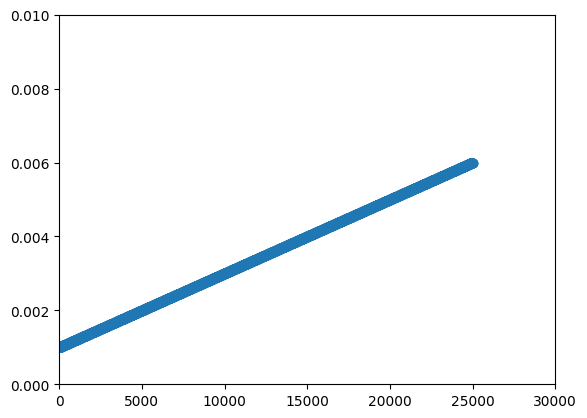

In [14]:
num_epochs = 50

batch_step = -1
collect_lr = []
for e in range(num_epochs):
    for i in range(iter_per_ep):
        batch_step += 1
        cur_lr = cyclical_learning_rate(batch_step=batch_step,
                                        step_size=num_epochs*iter_per_ep)
        
        collect_lr.append(cur_lr)
        
plt.scatter(range(len(collect_lr)), collect_lr)
plt.ylim([0.0, 0.01])
plt.xlim([0, num_epochs*iter_per_ep + 5000])
plt.show()

**Utility Functions**

In [15]:
def compute_accuracy(model, data_loader):
    correct_pred, num_examples = 0, 0
    for features, targets in data_loader:
        features = features.to(device)
        targets = targets.to(device)
        logits, probas = model(features)
        _, predicted_labels = torch.max(probas, 1)
        num_examples += targets.size(0)
        correct_pred += (predicted_labels == targets).sum()
    return correct_pred.float()/num_examples * 100

**Train Model/Run LR Range Test**

In [16]:
num_epochs = 10
iter_per_ep = len(train_loader)
base_lr = 0.01
max_lr = 0.2


torch.manual_seed(random_seed)
model = ConvNet(num_classes=num_classes)
model = model.to(device)


cost_fn = torch.nn.CrossEntropyLoss()  
optimizer = torch.optim.SGD(model.parameters(), lr=base_lr)  

collect = {'lr': [], 'cost': [], 'train_batch_acc': [], 'val_acc': []}

batch_step = -1
cur_lr = base_lr

start_time = time.time()
for epoch in range(num_epochs):
    for batch_idx, (features, targets) in enumerate(train_loader):
        
        batch_step += 1
        features = features.to(device)
        targets = targets.to(device)

        ### FORWARD AND BACK PROP
        logits, probas = model(features)
        cost = cost_fn(logits, targets)
        optimizer.zero_grad()

        cost.backward()

        ### UPDATE MODEL PARAMETERS
        optimizer.step()
        
        #############################################
        # Logging
        if not batch_step % 200:
            print('Total batch # %5d/%d' % (batch_step, 
                                            iter_per_ep*num_epochs), 
                  end='')
            print('   Curr. Batch Cost: %.5f' % cost)     

        #############################################
        # Collect stats    
        model = model.eval()
        train_acc = compute_accuracy(model, [[features, targets]])
        val_acc = compute_accuracy(model, val_loader)
        collect['lr'].append(cur_lr)
        collect['train_batch_acc'].append(train_acc)
        collect['val_acc'].append(val_acc)
        collect['cost'].append(cost)
        model = model.train()
        #############################################
        # update learning rate
        cur_lr = cyclical_learning_rate(batch_step=batch_step,
                                        step_size=num_epochs*iter_per_ep,
                                        base_lr=base_lr,
                                        max_lr=max_lr)
        for g in optimizer.param_groups:
            g['lr'] = cur_lr
        ############################################

    print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))
    
print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))

Total batch #     0/3130   Curr. Batch Cost: 2.31432
Total batch #   200/3130   Curr. Batch Cost: 2.30187
Time elapsed: 6.50 min
Total batch #   400/3130   Curr. Batch Cost: 2.30265
Total batch #   600/3130   Curr. Batch Cost: 2.30330
Time elapsed: 13.00 min
Total batch #   800/3130   Curr. Batch Cost: 2.30231
Time elapsed: 19.48 min
Total batch #  1000/3130   Curr. Batch Cost: 2.30207
Total batch #  1200/3130   Curr. Batch Cost: 2.30087
Time elapsed: 25.97 min
Total batch #  1400/3130   Curr. Batch Cost: 2.29376
Time elapsed: 32.48 min
Total batch #  1600/3130   Curr. Batch Cost: 2.10101
Total batch #  1800/3130   Curr. Batch Cost: 1.97555
Time elapsed: 38.98 min
Total batch #  2000/3130   Curr. Batch Cost: 1.99411
Time elapsed: 45.50 min
Total batch #  2200/3130   Curr. Batch Cost: 1.83589
Total batch #  2400/3130   Curr. Batch Cost: 1.63071
Time elapsed: 51.99 min
Total batch #  2600/3130   Curr. Batch Cost: 1.51865
Total batch #  2800/3130   Curr. Batch Cost: 1.55636
Time elapsed: 

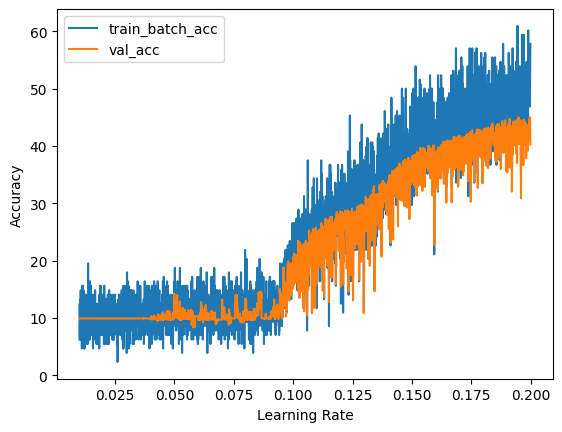

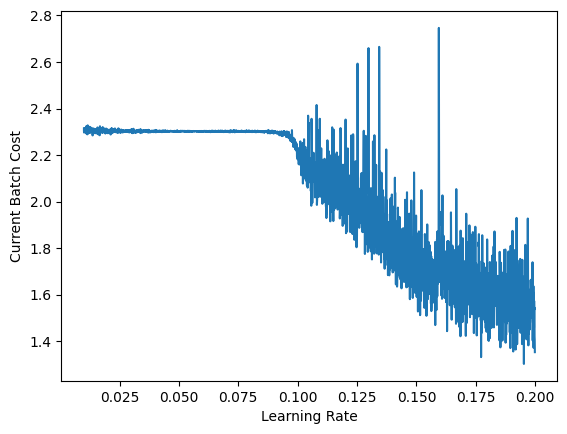

In [22]:
import numpy as np

def to_numpy(x):
    if isinstance(x, list):
        return [t.detach().cpu().numpy() if hasattr(t, "detach") else t for t in x]
    elif hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    else:
        return np.array(x)

collect_cpu = {k: to_numpy(v) for k, v in collect.items()}

plt.plot(collect_cpu['lr'], collect_cpu['train_batch_acc'], label='train_batch_acc')
plt.plot(collect_cpu['lr'], collect_cpu['val_acc'], label='val_acc')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(to_numpy(collect['lr']), to_numpy(collect['cost']))
plt.xlabel('Learning Rate')
plt.ylabel('Current Batch Cost')
plt.show()

## Train with Cyclical Learning Rate (`triangular`)

In [23]:
num_epochs = 150
iter_per_ep = len(train_loader.sampler.indices) // train_loader.batch_size
base_lr = 0.09
max_lr = 0.175

torch.manual_seed(random_seed)
model = ConvNet(num_classes=num_classes)
model = model.to(device)

cost_fn = torch.nn.CrossEntropyLoss()  
optimizer = torch.optim.SGD(model.parameters(), lr=base_lr)  

collect = {'epoch': [], 'cost': [], 'train_acc': [], 'val_acc': []}

start_time = time.time()
for epoch in range(num_epochs):
    epoch_avg_cost = 0.
    model = model.train()
    for batch_idx, (features, targets) in enumerate(train_loader):
        
        features = features.to(device)
        targets = targets.to(device)

        logits, probas = model(features)
        cost = cost_fn(logits, targets)
        optimizer.zero_grad()

        cost.backward()

        optimizer.step()

        epoch_avg_cost += cost
        
        if not batch_step % 600:
            print('Batch %5d/%d' % (batch_step, iter_per_ep*num_epochs),
                                    end='')
            print('   Cost: %.5f' % cost)     


    model = model.eval()
    train_acc = compute_accuracy(model, train_loader)
    val_acc = compute_accuracy(model, val_loader)
    epoch_avg_cost /= batch_idx+1
    collect['epoch'].append(epoch+1)
    collect['val_acc'].append(val_acc)
    collect['train_acc'].append(train_acc)
    collect['cost'].append(epoch_avg_cost / iter_per_ep)
    
    print('Epoch %3d' % (epoch+1), end='')
    print('  |  Train/Valid Acc: %.2f/%.2f' % (train_acc, val_acc))
    
    
    base_lr = cyclical_learning_rate(batch_step=batch_step,
                                     step_size=num_epochs*iter_per_ep,
                                     base_lr=base_lr,
                                     max_lr=max_lr)
    for g in optimizer.param_groups:
        g['lr'] = base_lr

    print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))
    
print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))

Epoch   1  |  Train/Valid Acc: 11.37/10.69
Time elapsed: 0.20 min
Epoch   2  |  Train/Valid Acc: 10.05/9.92
Time elapsed: 0.39 min
Epoch   3  |  Train/Valid Acc: 22.39/22.63
Time elapsed: 0.58 min
Epoch   4  |  Train/Valid Acc: 27.99/27.64
Time elapsed: 0.77 min
Epoch   5  |  Train/Valid Acc: 28.01/27.23
Time elapsed: 0.97 min
Epoch   6  |  Train/Valid Acc: 37.89/37.29
Time elapsed: 1.16 min
Epoch   7  |  Train/Valid Acc: 40.25/39.93
Time elapsed: 1.35 min
Epoch   8  |  Train/Valid Acc: 40.22/38.28
Time elapsed: 1.55 min
Epoch   9  |  Train/Valid Acc: 42.05/40.72
Time elapsed: 1.74 min
Epoch  10  |  Train/Valid Acc: 46.29/45.09
Time elapsed: 1.94 min
Epoch  11  |  Train/Valid Acc: 47.45/45.55
Time elapsed: 2.13 min
Epoch  12  |  Train/Valid Acc: 45.86/44.32
Time elapsed: 2.32 min
Epoch  13  |  Train/Valid Acc: 51.05/47.95
Time elapsed: 2.51 min
Epoch  14  |  Train/Valid Acc: 52.07/49.10
Time elapsed: 2.71 min
Epoch  15  |  Train/Valid Acc: 53.74/50.69
Time elapsed: 2.90 min
Epoch  16  

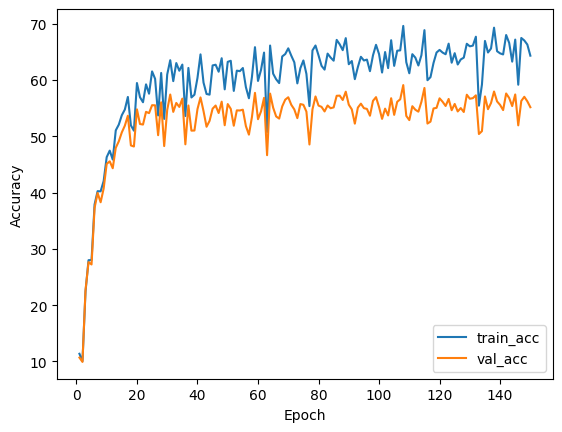

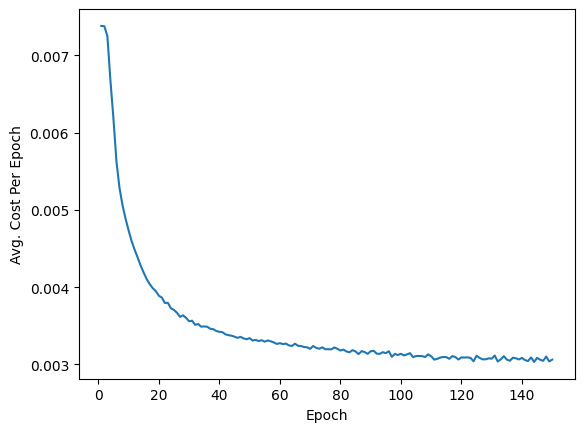

In [26]:
def to_numpy(x):
    if isinstance(x, list):
        arrs = [t.detach().cpu().numpy() if hasattr(t, "detach") else t for t in x]
        # If all are scalars -> flatten into 1D array
        if all(np.ndim(a) == 0 for a in arrs):
            return np.array(arrs)
        return np.stack(arrs) if all(isinstance(a, np.ndarray) for a in arrs) else np.array(arrs)
    elif hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    else:
        return np.array(x)

# --- Accuracy per epoch ---
plt.plot(to_numpy(collect['epoch']), to_numpy(collect['train_acc']), label='train_acc')
plt.plot(to_numpy(collect['epoch']), to_numpy(collect['val_acc']), label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# --- Cost per epoch ---
plt.plot(to_numpy(collect['epoch']), to_numpy(collect['cost']))
plt.xlabel('Epoch')
plt.ylabel('Avg. Cost Per Epoch')
plt.show()

In [27]:
print('Test accuracy: %.2f%%' % (compute_accuracy(model, test_loader)))

Test accuracy: 55.05%


## Train with Cyclical Learning Rate (`triangular2`)

In [29]:
num_epochs = 150
iter_per_ep = len(train_loader.sampler.indices) // train_loader.batch_size
base_lr = 0.09
max_lr = 0.175

torch.manual_seed(random_seed)
model = ConvNet(num_classes=num_classes)
model = model.to(device)

cost_fn = torch.nn.CrossEntropyLoss()  
optimizer = torch.optim.SGD(model.parameters(), lr=base_lr)  

collect = {'epoch': [], 'cost': [], 'train_acc': [], 'val_acc': []}

start_time = time.time()
for epoch in range(num_epochs):
    epoch_avg_cost = 0.
    model = model.train()
    for batch_idx, (features, targets) in enumerate(train_loader):
        
        features = features.to(device)
        targets = targets.to(device)

        ### FORWARD AND BACK PROP
        logits, probas = model(features)
        cost = cost_fn(logits, targets)
        optimizer.zero_grad()

        cost.backward()

        ### UPDATE MODEL PARAMETERS
        optimizer.step()

        epoch_avg_cost += cost
        
        if not batch_step % 600:
            print('Batch %5d/%d' % (batch_step, iter_per_ep*num_epochs),
                                    end='')
            print('   Cost: %.5f' % cost)     

    model = model.eval()
    train_acc = compute_accuracy(model, train_loader)
    val_acc = compute_accuracy(model, val_loader)
    epoch_avg_cost /= batch_idx+1
    collect['epoch'].append(epoch+1)
    collect['val_acc'].append(val_acc)
    collect['train_acc'].append(train_acc)
    collect['cost'].append(epoch_avg_cost / iter_per_ep)
    
    print('Epoch %3d' % (epoch+1), end='')
    print('  |  Train/Valid Acc: %.2f/%.2f' % (train_acc, val_acc))
    
    base_lr = cyclical_learning_rate(batch_step=batch_step,
                                     step_size=num_epochs*iter_per_ep,
                                     base_lr=base_lr,
                                     max_lr=max_lr,
                                     mode='triangular2')
    for g in optimizer.param_groups:
        g['lr'] = base_lr

    print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))
    
print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))    

Epoch   1  |  Train/Valid Acc: 11.37/10.69
Time elapsed: 0.21 min
Epoch   2  |  Train/Valid Acc: 10.05/9.92
Time elapsed: 0.43 min
Epoch   3  |  Train/Valid Acc: 22.39/22.63
Time elapsed: 0.64 min
Epoch   4  |  Train/Valid Acc: 27.99/27.64
Time elapsed: 0.84 min
Epoch   5  |  Train/Valid Acc: 28.01/27.23
Time elapsed: 1.04 min
Epoch   6  |  Train/Valid Acc: 37.89/37.29
Time elapsed: 1.24 min
Epoch   7  |  Train/Valid Acc: 40.25/39.93
Time elapsed: 1.43 min
Epoch   8  |  Train/Valid Acc: 40.22/38.28
Time elapsed: 1.63 min
Epoch   9  |  Train/Valid Acc: 42.05/40.72
Time elapsed: 1.82 min
Epoch  10  |  Train/Valid Acc: 46.29/45.09
Time elapsed: 2.01 min
Epoch  11  |  Train/Valid Acc: 47.45/45.55
Time elapsed: 2.21 min
Epoch  12  |  Train/Valid Acc: 45.86/44.32
Time elapsed: 2.40 min
Epoch  13  |  Train/Valid Acc: 51.05/47.95
Time elapsed: 2.60 min
Epoch  14  |  Train/Valid Acc: 52.07/49.10
Time elapsed: 2.79 min
Epoch  15  |  Train/Valid Acc: 53.74/50.69
Time elapsed: 2.98 min
Epoch  16  

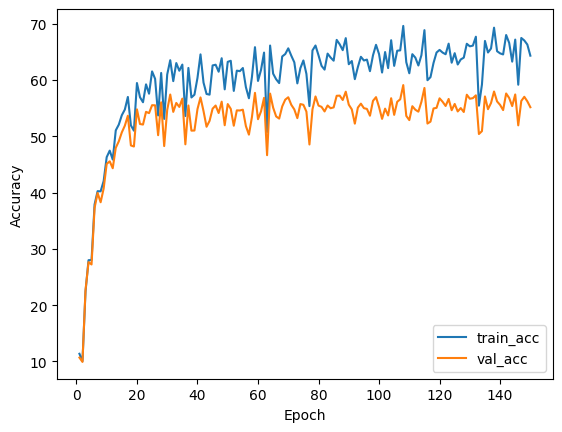

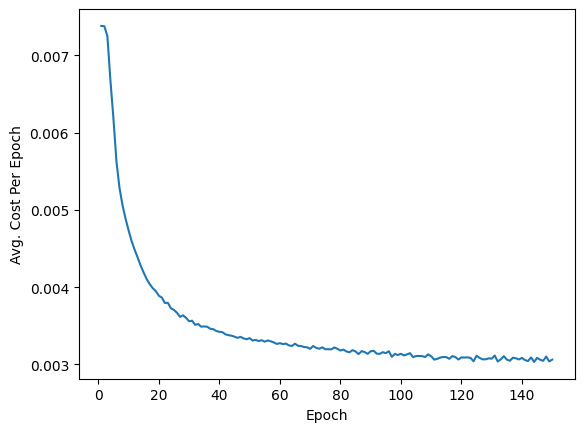

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def to_numpy(x):
    if isinstance(x, list):
        arrs = [t.detach().cpu().numpy() if hasattr(t, "detach") else t for t in x]
        # If all elements are scalars, flatten into 1D array
        if all(np.ndim(a) == 0 for a in arrs):
            return np.array(arrs)
        return np.stack(arrs) if all(isinstance(a, np.ndarray) for a in arrs) else np.array(arrs)
    elif hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    else:
        return np.array(x)

# --- Accuracy per epoch ---
plt.plot(to_numpy(collect['epoch']), to_numpy(collect['train_acc']), label='train_acc')
plt.plot(to_numpy(collect['epoch']), to_numpy(collect['val_acc']), label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# --- Cost per epoch ---
plt.plot(to_numpy(collect['epoch']), to_numpy(collect['cost']))
plt.xlabel('Epoch')
plt.ylabel('Avg. Cost Per Epoch')
plt.show()

In [32]:
print('Test accuracy: %.2f%%' % (compute_accuracy(model, test_loader)))

Test accuracy: 55.05%


## Train with Cyclical Learning Rate (`exp_range`)

In [34]:
num_epochs = 150
iter_per_ep = len(train_loader.sampler.indices) // train_loader.batch_size
base_lr = 0.09
max_lr = 0.175

torch.manual_seed(random_seed)
model = ConvNet(num_classes=num_classes)
model = model.to(device)

cost_fn = torch.nn.CrossEntropyLoss()  
optimizer = torch.optim.SGD(model.parameters(), lr=base_lr)  

collect = {'epoch': [], 'cost': [], 'train_acc': [], 'val_acc': []}

start_time = time.time()
for epoch in range(num_epochs):
    epoch_avg_cost = 0.
    model = model.train()
    for batch_idx, (features, targets) in enumerate(train_loader):
        
        features = features.to(device)
        targets = targets.to(device)

        ### FORWARD AND BACK PROP
        logits, probas = model(features)
        cost = cost_fn(logits, targets)
        optimizer.zero_grad()

        cost.backward()

        ### UPDATE MODEL PARAMETERS
        optimizer.step()

        epoch_avg_cost += cost
        
        if not batch_step % 600:
            print('Batch %5d/%d' % (batch_step, iter_per_ep*num_epochs),
                                    end='')
            print('   Cost: %.5f' % cost)     

    model = model.eval()
    train_acc = compute_accuracy(model, train_loader)
    val_acc = compute_accuracy(model, val_loader)
    epoch_avg_cost /= batch_idx+1
    collect['epoch'].append(epoch+1)
    collect['val_acc'].append(val_acc)
    collect['train_acc'].append(train_acc)
    collect['cost'].append(epoch_avg_cost / iter_per_ep)
    
    print('Epoch %3d' % (epoch+1), end='')
    print('  |  Train/Valid Acc: %.2f/%.2f' % (train_acc, val_acc))

    base_lr = cyclical_learning_rate(batch_step=batch_step,
                                     step_size=num_epochs*iter_per_ep,
                                     base_lr=base_lr,
                                     max_lr=max_lr,
                                     mode='exp_range')
    for g in optimizer.param_groups:
        g['lr'] = base_lr

    print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))
    
print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))

Epoch   1  |  Train/Valid Acc: 11.37/10.69
Time elapsed: 0.22 min
Epoch   2  |  Train/Valid Acc: 10.07/9.92
Time elapsed: 0.43 min
Epoch   3  |  Train/Valid Acc: 19.49/19.63
Time elapsed: 0.64 min
Epoch   4  |  Train/Valid Acc: 28.11/27.33
Time elapsed: 0.85 min
Epoch   5  |  Train/Valid Acc: 26.89/26.47
Time elapsed: 1.04 min
Epoch   6  |  Train/Valid Acc: 38.79/38.25
Time elapsed: 1.24 min
Epoch   7  |  Train/Valid Acc: 40.18/40.02
Time elapsed: 1.44 min
Epoch   8  |  Train/Valid Acc: 39.72/38.30
Time elapsed: 1.64 min
Epoch   9  |  Train/Valid Acc: 41.83/39.94
Time elapsed: 1.83 min
Epoch  10  |  Train/Valid Acc: 43.72/42.92
Time elapsed: 2.02 min
Epoch  11  |  Train/Valid Acc: 48.47/46.47
Time elapsed: 2.22 min
Epoch  12  |  Train/Valid Acc: 46.18/44.46
Time elapsed: 2.41 min
Epoch  13  |  Train/Valid Acc: 50.71/48.80
Time elapsed: 2.60 min
Epoch  14  |  Train/Valid Acc: 50.06/47.72
Time elapsed: 2.80 min
Epoch  15  |  Train/Valid Acc: 55.12/52.28
Time elapsed: 2.99 min
Epoch  16  

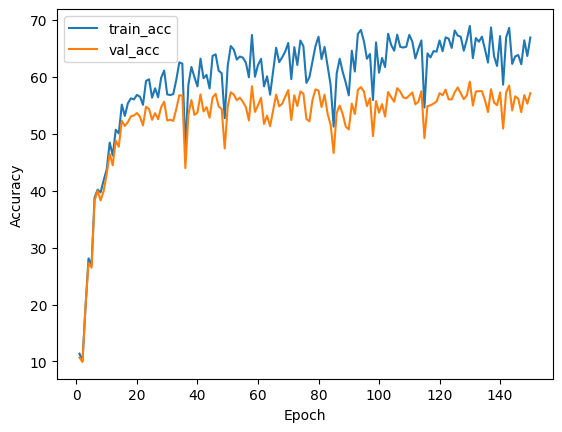

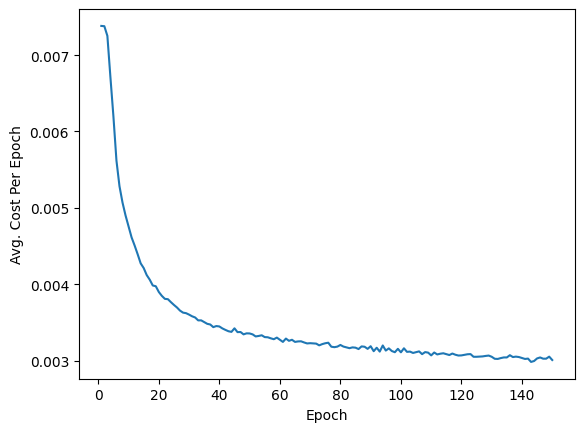

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def to_numpy(x):
    if isinstance(x, list):
        arrs = [t.detach().cpu().numpy() if hasattr(t, "detach") else t for t in x]
        # If all are scalars -> flatten into 1D array
        if all(np.ndim(a) == 0 for a in arrs):
            return np.array(arrs)
        return np.stack(arrs) if all(isinstance(a, np.ndarray) for a in arrs) else np.array(arrs)
    elif hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    else:
        return np.array(x)

# --- Accuracy per epoch ---
plt.plot(to_numpy(collect['epoch']), to_numpy(collect['train_acc']), label='train_acc')
plt.plot(to_numpy(collect['epoch']), to_numpy(collect['val_acc']), label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# --- Cost per epoch ---
plt.plot(to_numpy(collect['epoch']), to_numpy(collect['cost']))
plt.xlabel('Epoch')
plt.ylabel('Avg. Cost Per Epoch')
plt.show()

In [37]:
print('Test accuracy: %.2f%%' % (compute_accuracy(model, test_loader)))

Test accuracy: 56.63%
